In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [2]:
class MultipleLinearRegression:
    def __init__(self):
        self.coefficients_ = None
        self.intercept_ = None
        self.r2score_ = None

    def fit(self, X, y):
        n = X.shape[0]
        X_b = np.c_[np.ones((n,1)), X]
        self.coefficients_ = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
        self.intercept_ = self.coefficients_[0]
        y_pred = X_b.dot(self.coefficients_)
        self.r2score_ = 1 - (np.sum((y - y_pred)**2)/np.sum((y - np.mean(y))**2))
        self.y_pred_ = y_pred

    def predict(self, X):
        X_b = np.c_[np.ones((X.shape[0],1)), X]
        return X_b.dot(self.coefficients_)

In [3]:
np.random.seed(0)
X1 = np.random.randint(1, 11, 15)
X2 = np.random.randint(1, 11, 15)
X_multi = np.column_stack((X1, X2))
y_multi = 1 + 2*X1 + 3*X2 + np.random.randn(15)*2

Multiple LR Coefficients: [-1.45333931  2.15806389  3.32011421]
R² Score: 0.95


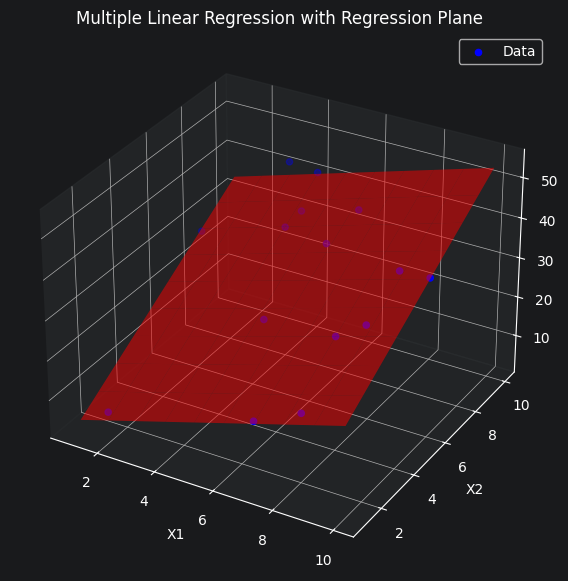

In [4]:
mlr = MultipleLinearRegression()
mlr.fit(X_multi, y_multi)
print(f"Multiple LR Coefficients: {mlr.coefficients_}")
print(f"R² Score: {mlr.r2score_:.2f}")

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_multi[:,0], X_multi[:,1], y_multi, color='blue', label='Data')

x1_surf, x2_surf = np.meshgrid(
    np.linspace(X_multi[:,0].min(), X_multi[:,0].max(), 10),
    np.linspace(X_multi[:,1].min(), X_multi[:,1].max(), 10)
)

pred_surf = mlr.predict(np.c_[x1_surf.ravel(), x2_surf.ravel()]).reshape(x1_surf.shape)

ax.plot_surface(x1_surf, x2_surf, pred_surf, color='red', alpha=0.5, rstride=1, cstride=1)

ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('y')
ax.set_title("Multiple Linear Regression with Regression Plane")
ax.legend()
plt.show()